In [4]:
import os
import sys
from pathlib import Path
import time

if os.getcwd().endswith("scripts"):
    os.chdir("..")
sys.path.insert(0, "src")

import yaml
import torch

from utils import resolve_device, set_seed, plot_history
from data import get_loaders
from models import PlainCNN



In [5]:
config_path = "configs.yaml"
with open(config_path, "r") as f:   
    cfg = yaml.safe_load(f)

device = resolve_device(cfg["device"])
print(f"Device: {device}")

SEED = cfg.get("seed", 42)
set_seed(SEED)
print(f"Random seed set to: {SEED}")


Device: xpu
Random seed set to: 42


In [6]:
train_loader, val_loader, test_loader = get_loaders(
    data_dir="data",
    batch_size=cfg["data"]["batch_size"],
    num_workers=cfg["data"]["num_workers"],
    augment=cfg["train"]["augment"]
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of testing batches: {len(test_loader)}")


Number of training batches: 704
Number of validation batches: 79
Number of testing batches: 157


In [7]:
plain_cnn = PlainCNN(num_classes=cfg["model"]["num_classes"]).to(device)
plain_cnn_optimizer = torch.optim.Adam(plain_cnn.parameters(), lr=1e-3)

criterion = torch.nn.CrossEntropyLoss()

print(plain_cnn)
print(f"Number of parameters: {sum(p.numel() for p in plain_cnn.parameters())}")

PlainCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128

In [8]:
def train_one_epoch(model, optimizer, criterion, loader, device):
    """returns: avg_loss, avg_acc"""
    model.train()
    total_loss = 0
    total_correct = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(loader)
    avg_acc = total_correct / len(loader.dataset)

    return avg_loss, avg_acc


def evaluate(model, criterion, loader, device):
    """returns: avg_loss, avg_acc"""
    model.eval()
    total_loss = 0
    total_correct = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb) 
            loss = criterion(logits, yb)
            preds = logits.argmax(dim=1)

            total_correct += (preds == yb).sum().item()
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    avg_acc = total_correct / len(loader.dataset)

    return avg_loss, avg_acc


def train(model, optimizer, criterion, train_loader, val_loader, device, epochs, ckpt_dir):
    history = {}
    history["train_loss"] = []
    history["train_acc"] = []
    history["val_loss"] = []
    history["val_acc"] = []

    format_n = len(str(epochs))

    best_val_acc = 0
    ckpt_dir = Path(ckpt_dir)
    ckpt_dir.mkdir(exist_ok=True)
    
    for epoch in range(epochs):
        start = time.time()
        ts = time.strftime("%H:%M:%S", time.localtime(start))

        train_loss, train_acc = train_one_epoch(model, optimizer, criterion, train_loader, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        val_loss, val_acc = evaluate(model, criterion, val_loader, device)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        duration = time.time() - start

        print(
            f"[{ts}] Epoch {epoch+1:0{format_n}d}/{epochs}\n"
            f"Train: [{train_loss:.4f}, {train_acc:.4f}] | "
            f"Val: [{val_loss:.4f}, {val_acc:.4f}] | "
            f"{duration:.2f}s"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), ckpt_dir / "best_plain_cnn.pt")
            print(f"New best model saved at {ckpt_dir / 'best_plain_cnn.pt'} with val_acc: {best_val_acc:.4f}")

        print()

    return history



[21:28:46] Epoch 01/30
Train: [1.2210, 0.5572] | Val: [1.1618, 0.5884] | 18.72s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.5884

[21:29:04] Epoch 02/30
Train: [0.8387, 0.7022] | Val: [1.5234, 0.5342] | 16.11s

[21:29:21] Epoch 03/30
Train: [0.6713, 0.7653] | Val: [0.7123, 0.7552] | 16.62s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.7552

[21:29:37] Epoch 04/30
Train: [0.5661, 0.8042] | Val: [0.6646, 0.7684] | 16.29s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.7684

[21:29:53] Epoch 05/30
Train: [0.4955, 0.8277] | Val: [0.7870, 0.7418] | 27.56s

[21:30:21] Epoch 06/30
Train: [0.4379, 0.8475] | Val: [0.5279, 0.8144] | 29.11s
New best model saved at checkpoints\best_plain_cnn.pt with val_acc: 0.8144

[21:30:50] Epoch 07/30
Train: [0.3859, 0.8669] | Val: [0.5504, 0.8130] | 28.28s

[21:31:18] Epoch 08/30
Train: [0.3401, 0.8818] | Val: [0.5808, 0.8052] | 27.57s

[21:31:46] Epoch 09/30
Train: [0.3009, 0.8958] | Val

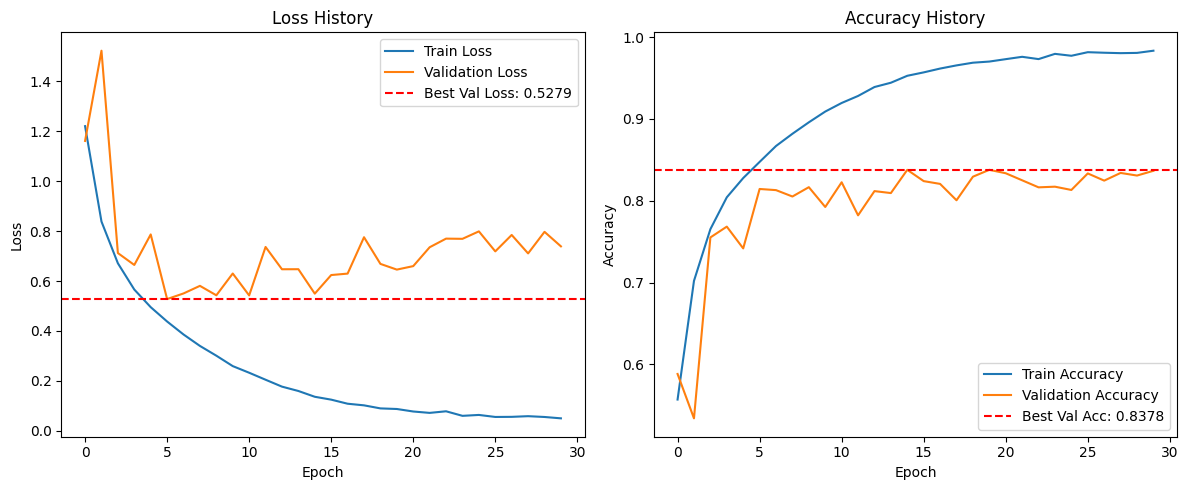

In [9]:
epochs = cfg.get("train", {}).get("epochs", 10)
ckpt_dir = cfg.get("train", {}).get("checkpoint_dir", "checkpoints")
ckpt_dir = Path(ckpt_dir)

history = train(
    model=plain_cnn,
    optimizer=plain_cnn_optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    ckpt_dir=ckpt_dir
)

plot_history(history)


In [10]:
print(f"Loading best model for testing from {ckpt_dir / 'best_plain_cnn.pt'}")
plain_cnn.load_state_dict(torch.load(ckpt_dir / "best_plain_cnn.pt"))

test_loss, test_acc = evaluate(plain_cnn, criterion, test_loader, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


Loading best model for testing from checkpoints\best_plain_cnn.pt
Test Loss: 0.6127 | Test Acc: 0.8326
